In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [42]:
def f(x):
    """
    Функция, представляющая исходное нелинейное уравнение
    2*ln(x+1) - (1/x) = 0
    """
    return 2 * math.log(x + 1) - (1 / x)

In [43]:
def find_root_interval(start, end, step=0.1):
    """
    Поиск интервалов, где функция меняет знак
    """
    intervals = []
    x = start
    while x < end:
        if f(x) * f(x + step) <= 0:
            intervals.append((x, x + step))
        x += step
    return intervals

In [44]:
def half_division_method(a, b, eps=1e-5):
    """
    Метод половинного деления (дихотомии)
    """
    iterations = 0
    while (b - a) / 2 > eps:
        x = (a + b) / 2

        if f(x) == 0:
            return x, iterations

        if f(a) * f(x) < 0:
            b = x
        else:
            a = x

        iterations += 1

    return (a + b) / 2, iterations

In [45]:
def combined_method(a, b, eps=1e-5):
    """
    Комбинированный метод решения нелинейных уравнений
    """
    x0 = a
    x1 = b
    iterations = 0

    while abs(x1 - x0) > eps:
        def df(x):
            h = 1e-5
            return (f(x + h) - f(x)) / h

        x_next = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        x0, x1 = x1, x_next

        iterations += 1

        if iterations > 1000:
            break

    return x1, iterations

In [46]:
def iteration_method(a, b, eps=1e-5):
    """
    Метод простых итераций
    """
    def phi(x):
        return (1 / (2 * math.log(x + 1)))

    x0 = (a + b) / 2
    iterations = 0

    while True:
        x1 = phi(x0)

        if abs(x1 - x0) < eps:
            return x1, iterations

        x0 = x1
        iterations += 1

        if iterations > 1000:
            break

    return x1, iterations

In [47]:
def plot_function_with_intervals(intervals):
    """
    Построение графика функции с отмеченными интервалами корней
    """
    if not intervals:
        print("Интервалы не найдены!")
        return

    x_min = max(0.1, intervals[0][0] - 1)
    x_max = intervals[-1][1] + 1

    x = np.linspace(x_min, x_max, 200)

    y = [f(xi) for xi in x]

    plt.figure(figsize=(12, 6))
    plt.title('График функции 2*ln(x+1) - (1/x)')
    plt.xlabel('x')
    plt.ylabel('f(x)')

    # Построение линии функции
    plt.plot(x, y, label='f(x) = 2*ln(x+1) - (1/x)')

    # Горизонтальная линия на уровне 0
    plt.axhline(y=0, color='r', linestyle='--')

    # Отметки интервалов и корней
    for interval in intervals:
        a, b = interval
        plt.plot((a, b), (f(a), f(b)), 'ro-', label=f'Интервал [{a:.2f}, {b:.2f}]')
        plt.text((a+b)/2, f((a+b)/2), f'[{a:.2f}, {b:.2f}]',
                 verticalalignment='bottom',
                 horizontalalignment='center')

    plt.grid(True)
    plt.legend()
    plt.show()

In [48]:
def main():
    # Поиск интервалов с корнями
    root_intervals = find_root_interval(0.01, 10)

    print("Найденные интервалы с корнями:")
    for interval in root_intervals:
        a, b = interval
        print(f"\nИнтервал [{a}, {b}]")

        print("\nМетод половинного деления:")
        root_half, iter_half = half_division_method(a, b)
        print(f"Корень: {root_half}")
        print(f"Значение функции: {f(root_half)}")
        print(f"Количество итераций: {iter_half}")

        print("\nКомбинированный метод:")
        root_combined, iter_combined = combined_method(a, b)
        print(f"Корень: {root_combined}")
        print(f"Значение функции: {f(root_combined)}")
        print(f"Количество итераций: {iter_combined}")

        print("\nМетод итераций:")
        root_iteration, iter_iteration = iteration_method(a, b)
        print(f"Корень: {root_iteration}")
        print(f"Значение функции: {f(root_iteration)}")
        print(f"Количество итераций: {iter_iteration}")
        print("-" * 50)

    plot_function_with_intervals(root_intervals)

Найденные интервалы с корнями:

Интервал [0.8099999999999999, 0.9099999999999999]

Метод половинного деления:
Корень: 0.8284997558593751
Значение функции: -9.309001447688203e-06
Количество итераций: 13

Комбинированный метод:
Корень: 0.8285034055415419
Значение функции: 1.1752154804867132e-11
Количество итераций: 4

Метод итераций:
Корень: 0.828499136073517
Значение функции: -1.0889855434292883e-05
Количество итераций: 30
--------------------------------------------------


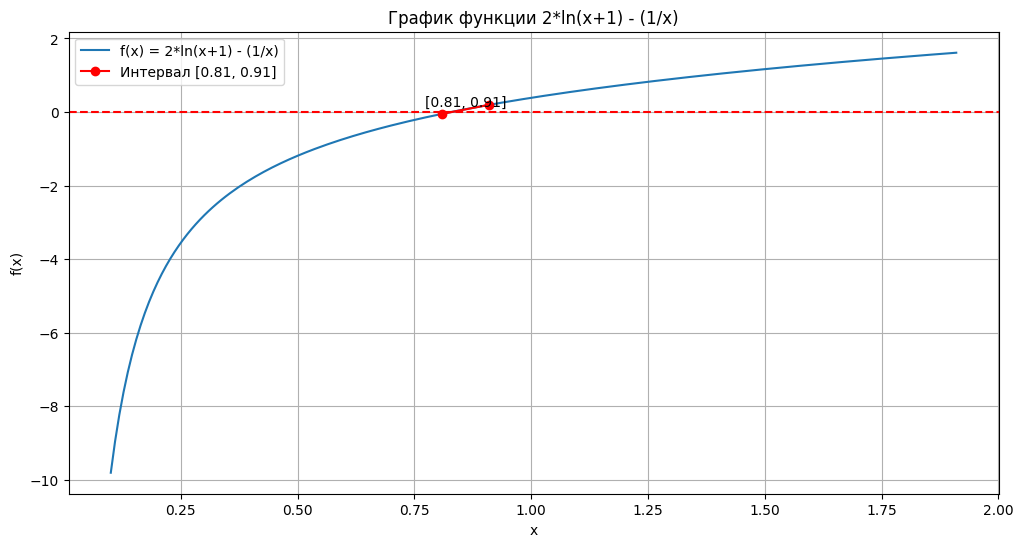

In [49]:
if __name__ == "__main__":
    main()